# Evaluation and statistics

This notebook demonstrates every metric and statistical test described in Section 4 (Proposed Methods and Evaluation) of the research plan.
The functions are defined in `eval_stats.py`. Each section below explains what a function does and why it is needed, then shows its output.

> **Note:** all data in this notebook are **synthetic**. They come from a simulated classifier with known accuracy, which lets us check that the code recovers the effects we built in.
> These are not project results.

**Setup:** three models (ANN = EEGNet; SNN = EEGNet converted to a spiking network; RSNN = recurrent spiking network), 9 subjects and 10 repeats, giving 90 folds per model.
Each fold is tested on the target subject's session 2: **288 trials, 72 per class, 4 classes**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.stats import binom
import eval_stats as es

print("numpy", np.__version__, "| scipy", scipy.__version__)
rng = np.random.default_rng(0)
CLASSES = ["left hand", "right hand", "feet", "tongue"]

numpy 2.5.3 | scipy 1.18.1


## 1. Simulated predictions
`fake_predictions` simulates a classifier. Each trial is classified correctly with probability `acc`; otherwise it is assigned one of the three wrong classes at random.
Each subject is given a different baseline accuracy, because decoding performance varies widely between people.
The three models then differ by small, known amounts: **the RSNN is 3 percentage points above the SNN**, and **the SNN is 2 points below the ANN** (the simulated conversion loss).

In [2]:
def fake_predictions(y_true, acc, rng):
    correct = rng.random(y_true.size) < acc
    wrong = (y_true + rng.integers(1, 4, y_true.size)) % 4      # any class except the true one
    return np.where(correct, y_true, wrong)

y_true = np.repeat(np.arange(4), 72)          # 288 balanced test trials
rng.shuffle(y_true)
subject_base = rng.uniform(0.45, 0.80, size=9) # per-subject difficulty
offset = {"ANN": 0.0, "SNN": -0.02, "RSNN": 0.01}

records = []
for s in range(1, 10):
    for rep in range(10):
        for m in ["ANN", "SNN", "RSNN"]:
            acc = np.clip(subject_base[s-1] + offset[m] + rng.normal(0, 0.02), 0.25, 0.99)
            records.append({"model": m, "subject": s, "repeat": rep, "seed": 100 * s + rep,
                            "y_true": y_true, "y_pred": fake_predictions(y_true, acc, rng)})

print(len(records), "fold records =", 3, "models x 9 subjects x 10 repeats")
print("one record:", {k: (v.shape if hasattr(v, 'shape') else v) for k, v in records[0].items()})
print("class counts in y_true:", np.bincount(y_true))

270 fold records = 3 models x 9 subjects x 10 repeats
one record: {'model': 'ANN', 'subject': 1, 'repeat': 0, 'seed': 100, 'y_true': (288,), 'y_pred': (288,)}
class counts in y_true: [72 72 72 72]


## 2. Metrics for a single fold
- **Accuracy** is the fraction of trials classified correctly. It is the primary metric because it is the metric reported for EEGNet.
- **Cohen's kappa** is $(p_o - p_e)/(1 - p_e)$, the agreement beyond what chance alone would produce. With balanced classes $p_e = 0.25$, so kappa = (accuracy − 0.25)/0.75. A value of 0 means chance level and 1 means perfect classification.
- **Macro-F1** averages the F1 scores of the four classes, so good performance on some classes cannot hide poor performance on another.
- **The confusion matrix** shows which classes are confused with each other. Rows are the true class and columns the predicted class.

Balanced accuracy is not reported separately: with exactly 72 trials per class, it is identical to accuracy.

fold: model=ANN subject=1 repeat=0
  accuracy  = 0.712
  kappa     = 0.616
  macro_f1  = 0.711
  kappa check via (acc-0.25)/0.75 = 0.616
confusion counts (rows=true):
 [[48  6 11  7]
 [ 9 47 11  5]
 [ 3  1 59  9]
 [11  6  4 51]]


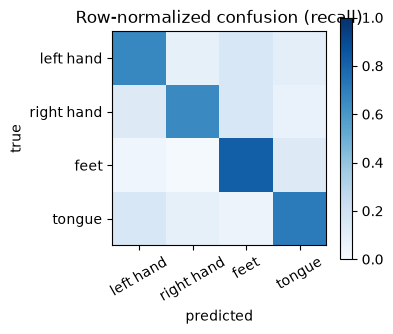

In [3]:
r = records[0]
fm = es.fold_metrics(r["y_true"], r["y_pred"])
print(f"fold: model={r['model']} subject={r['subject']} repeat={r['repeat']}")
for k in ["accuracy", "kappa", "macro_f1"]:
    print(f"  {k:9s} = {fm[k]:.3f}")
print(f"  kappa check via (acc-0.25)/0.75 = {(fm['accuracy']-0.25)/0.75:.3f}")
print("confusion counts (rows=true):\n", fm["confusion"])

fig, ax = plt.subplots(figsize=(4, 3.5))
im = ax.imshow(es.row_normalize(fm["confusion"]), vmin=0, vmax=1, cmap="Blues")
ax.set_xticks(range(4), CLASSES, rotation=30); ax.set_yticks(range(4), CLASSES)
ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title("Row-normalized confusion (recall)")
fig.colorbar(im); plt.tight_layout(); plt.show()

## 3. Comparison with chance (1): binomial threshold
Chance level is not simply 25%. With a finite test set of 288 trials, a classifier that is only guessing can exceed 25% by luck (Combrisson & Jerbi, 2015).
The binomial threshold answers this question: if the classifier were guessing, how many correct trials would be needed before the result becomes unlikely (α = 0.05)?

binom.ppf(0.95) = 84  ->  threshold = 84/288 = 0.2917
P(X >= 84)   = 0.061   (NOT significant)
P(X >= 85) = 0.046   (significant)  -> need >= 85 correct, i.e. acc > 0.2917


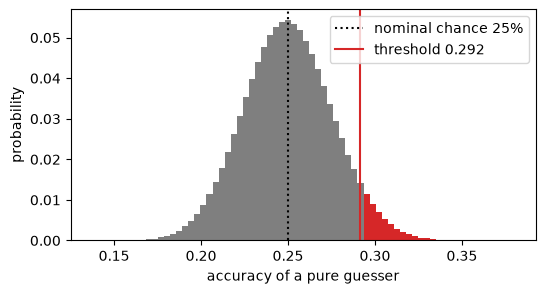

In [4]:
n, p, alpha = 288, 0.25, 0.05
k = int(binom.ppf(1 - alpha, n, p))
thr = es.binomial_threshold(n)
print(f"binom.ppf(0.95) = {k}  ->  threshold = {k}/{n} = {thr:.4f}")
print(f"P(X >= {k})   = {binom.sf(k-1, n, p):.3f}   (NOT significant)")
print(f"P(X >= {k+1}) = {binom.sf(k, n, p):.3f}   (significant)  -> need >= {k+1} correct, i.e. acc > {thr:.4f}")

x = np.arange(40, 110)
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(x / n, binom.pmf(x, n, p), width=1/n, color=["tab:red" if xi > k else "tab:gray" for xi in x])
ax.axvline(0.25, ls=":", c="k", label="nominal chance 25%")
ax.axvline(thr, c="tab:red", label=f"threshold {thr:.3f}")
ax.set_xlabel("accuracy of a pure guesser"); ax.set_ylabel("probability"); ax.legend(); plt.show()

## 4. Comparison with chance (2): permutation test
The second check makes no assumption about the shape of the distribution. The true labels are shuffled 10,000 times while the predictions stay fixed.
Each shuffle shows the accuracy to expect when predictions and labels are unrelated.
The p-value is the proportion of shuffles that score at least as high as the real labels. One is added to the numerator and to the denominator so that p is never exactly zero.
A result is called **above chance only if it passes both checks.**

observed acc = 0.712, null mean = 0.250, p_perm = 0.00010
chance_assessment: {'accuracy': 0.7118055555555556, 'threshold': 0.2916666666666667, 'p_perm': 9.999000099990002e-05, 'above_chance': True}


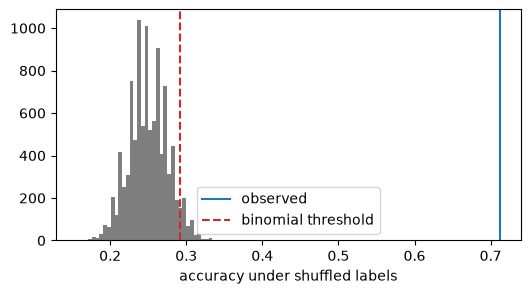

In [5]:
obs = fm["accuracy"]
rng_p = np.random.default_rng(1)
null = np.array([np.mean(rng_p.permutation(r["y_true"]) == r["y_pred"]) for _ in range(10_000)])
p_perm = es.permutation_pvalue(r["y_true"], r["y_pred"], 10_000, seed=1)
print(f"observed acc = {obs:.3f}, null mean = {null.mean():.3f}, p_perm = {p_perm:.5f}")
print("chance_assessment:", es.chance_assessment(r["y_true"], r["y_pred"], seed=1))

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(null, bins=40, color="tab:gray"); ax.axvline(obs, c="tab:blue", label="observed")
ax.axvline(thr, c="tab:red", ls="--", label="binomial threshold")
ax.set_xlabel("accuracy under shuffled labels"); ax.legend(); plt.show()

## 5. The subject as the unit of analysis
The 10 repeats for one subject share the same person, electrode placement and recording session, so they are **not independent**.
Treating the 90 folds as 90 independent results would make the statistics appear far more certain than they are.
The 10 repeats are therefore averaged to **one value per subject, model and metric**, giving 9 paired values per model.

subject   ANN    SNN    RSNN   (mean accuracy over 10 repeats)
  A01   0.708  0.683  0.717
  A02   0.506  0.486  0.538
  A03   0.570  0.561  0.616
  A04   0.476  0.444  0.478
  A05   0.718  0.670  0.728
  A06   0.473  0.450  0.495
  A07   0.597  0.576  0.607
  A08   0.751  0.738  0.767
  A09   0.636  0.603  0.602


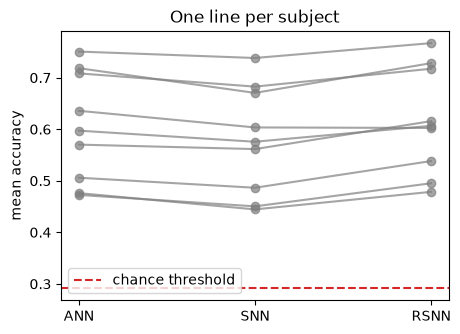

In [6]:
subject_means = {m: {k: [] for k in es.METRICS} for m in ["ANN", "SNN", "RSNN"]}
for m in subject_means:
    for s in range(1, 10):
        accs = [es.fold_metrics(r["y_true"], r["y_pred"])["accuracy"]
                for r in records if r["model"] == m and r["subject"] == s]
        for k in es.METRICS:
            vals = [es.fold_metrics(r["y_true"], r["y_pred"])[k]
                    for r in records if r["model"] == m and r["subject"] == s]
            subject_means[m][k].append(np.mean(vals))

print("subject   ANN    SNN    RSNN   (mean accuracy over 10 repeats)")
for i in range(9):
    print(f"  A0{i+1}   " + "  ".join(f"{subject_means[m]['accuracy'][i]:.3f}" for m in ["ANN", "SNN", "RSNN"]))

fig, ax = plt.subplots(figsize=(5, 3.5))
for i in range(9):
    ax.plot(["ANN", "SNN", "RSNN"], [subject_means[m]["accuracy"][i] for m in ["ANN", "SNN", "RSNN"]],
            marker="o", c="tab:gray", alpha=0.7)
ax.axhline(thr, c="tab:red", ls="--", label="chance threshold")
ax.set_ylabel("mean accuracy"); ax.set_title("One line per subject"); ax.legend(); plt.show()

### Why the subject-level chance test uses n = 288, not 2,880
All 10 repeats classify **the same 288 test trials**. Pooling them as 2,880 trials would overstate the amount of data tenfold and pull the threshold towards 25%, making chance easier to beat than it should be.
For this reason, `subject_permutation_pvalue` applies **one** shuffle of the 288 labels to all 10 repeats at once.

In [7]:
print(f"threshold with n=288 : {es.binomial_threshold(288):.4f}")
print(f"threshold with n=2880: {es.binomial_threshold(2880):.4f}   <- too lenient")
s = 1
P = np.stack([r["y_pred"] for r in records if r["model"] == "RSNN" and r["subject"] == s])
print("RSNN subject A01: repeats x trials =", P.shape,
      "| p_subject =", es.subject_permutation_pvalue(y_true, P, 10_000, seed=2))

threshold with n=288 : 0.2917
threshold with n=2880: 0.2632   <- too lenient
RSNN subject A01: repeats x trials = (10, 288) | p_subject = 9.999000099990002e-05


## 6. Comparing models: exact Wilcoxon signed-rank test with Holm correction
For each pair of models, the 9 subject-level differences are ranked by size, and the test compares the ranks of the positive and negative differences.
With only 9 subjects the **exact** version of the test is used. It considers all 2⁹ = 512 possible sign patterns, so it does not assume normally distributed data.
The smallest possible two-sided p-value is 2/512 ≈ 0.0039. This is below the strictest Holm cutoff (0.05/3 ≈ 0.0167), so a significant result is achievable with this sample size.

**Holm correction** accounts for making three comparisons. The p-values are sorted, then the smallest is multiplied by 3, the next by 2 and the largest by 1, and the adjusted values are kept in non-decreasing order.

In [8]:
d = np.array(subject_means["RSNN"]["accuracy"]) - np.array(subject_means["SNN"]["accuracy"])
print("RSNN - SNN per subject:", np.round(d, 3))
print("ranks of |d|:", scipy.stats.rankdata(np.abs(d)).astype(int))
print("wilcoxon_exact:", es.wilcoxon_exact(subject_means["RSNN"]["accuracy"], subject_means["SNN"]["accuracy"]))
print("min possible two-sided p with n=9:", 2 / 2**9)
print("Holm demo: raw [0.01, 0.04, 0.03] ->", es.holm([0.01, 0.04, 0.03]))

RSNN - SNN per subject: [ 0.035  0.052  0.054  0.034  0.058  0.045  0.031  0.029 -0.001]
ranks of |d|: [5 7 8 4 9 6 3 2 1]
wilcoxon_exact: {'W': 1.0, 'p': 0.0078125, 'n_eff': 9, 'n_zero': 0, 'has_ties': False}
min possible two-sided p with n=9: 0.00390625
Holm demo: raw [0.01, 0.04, 0.03] -> [0.03 0.06 0.06]


## 7. Size of the difference: bootstrap confidence interval of the median
A p-value indicates whether a difference is likely to be real, not how large it is. To estimate its size, the 9 subjects are resampled with replacement 10,000 times, and the median difference is recorded each time.
The middle 95% of these medians forms the confidence interval. With only 9 subjects the interval is coarse, so it is reported together with the observed median.

{'median': 0.03472222222222221, 'ci_low': 0.02881944444444451, 'ci_high': 0.054166666666666696}


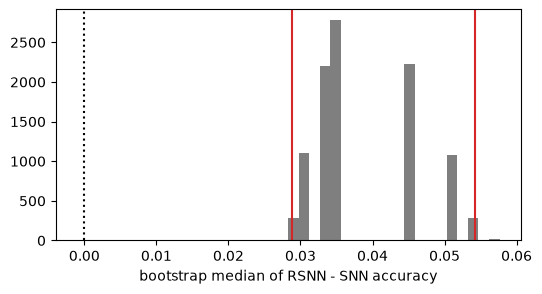

In [9]:
bs = es.bootstrap_median_ci(d, 10_000, seed=3)
boot = np.median(np.random.default_rng(3).choice(d, size=(10_000, 9)), axis=1)
print(bs)
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(boot, bins=40, color="tab:gray"); ax.axvline(0, c="k", ls=":")
for v in (bs["ci_low"], bs["ci_high"]): ax.axvline(v, c="tab:red")
ax.set_xlabel("bootstrap median of RSNN - SNN accuracy"); plt.show()

## 8. Full evaluation: `evaluate()`
`evaluate()` runs all of the steps above in one call. On real data, it takes the prediction files saved by the training pipeline (`es.load_predictions(folder)`).
It first checks that all three models were evaluated on identical folds and test labels, then computes every metric and test.
The simulated data were built with the RSNN 3 points above the SNN, so the comparison should recover a difference of about that size.

In [10]:
res = es.evaluate(records, {"n_permutations": 2000, "n_bootstrap": 5000})   # fewer permutations to keep this demo fast
print("across subjects (mean ± SD of 9 subject means):")
for m, v in res["across_subjects"].items():
    print(f"  {m:5s} acc {v['accuracy']['mean']:.3f} ± {v['accuracy']['sd']:.3f} | "
          f"kappa {v['kappa']['mean']:.3f} | F1 {v['macro_f1']['mean']:.3f}")
print("\nchance:", res["chance_summary"])
print("\naccuracy comparisons:")
for row in res["comparisons"]["accuracy"]:
    print(f"  {row['pair']:9s} median d = {row['median']:+.3f} [{row['ci_low']:+.3f}, {row['ci_high']:+.3f}]"
          f"  W={row['W']:.0f}  p={row['p']:.4f}  p_holm={row['p_holm']:.4f}  n_eff={row['n_eff']} ties={row['has_ties']}")

from pathlib import Path
Path("outputs").mkdir(exist_ok=True)
es.save_results(res, "outputs/synthetic_results.json")
print("\nsaved outputs/synthetic_results.json (synthetic, not project results)")

across subjects (mean ± SD of 9 subject means):
  ANN   acc 0.604 ± 0.107 | kappa 0.472 | F1 0.604
  RSNN  acc 0.617 ± 0.103 | kappa 0.489 | F1 0.616
  SNN   acc 0.579 ± 0.105 | kappa 0.439 | F1 0.579

chance: {'ANN': {'folds_above_chance': 90, 'n_folds': 90, 'subjects_above_chance': 9, 'n_subjects': 9}, 'RSNN': {'folds_above_chance': 90, 'n_folds': 90, 'subjects_above_chance': 9, 'n_subjects': 9}, 'SNN': {'folds_above_chance': 90, 'n_folds': 90, 'subjects_above_chance': 9, 'n_subjects': 9}}

accuracy comparisons:
  RSNN-SNN  median d = +0.035 [+0.029, +0.054]  W=1  p=0.0078  p_holm=0.0156  n_eff=9 ties=False
  RSNN-ANN  median d = +0.010 [+0.002, +0.032]  W=8  p=0.0977  p_holm=0.0977  n_eff=9 ties=False
  ANN-SNN   median d = +0.022 [+0.013, +0.032]  W=0  p=0.0039  p_holm=0.0117  n_eff=9 ties=False

saved outputs/synthetic_results.json (synthetic, not project results)


## 9. Sanity checks
Two quick checks confirm that the code behaves as expected. A perfect classifier should score exactly 1 on every metric, and a random guesser should stay near 25% and be called above chance in no more than about 5% of tests.

In [11]:
perfect = es.fold_metrics(y_true, y_true)
print("perfect:", {k: perfect[k] for k in es.METRICS})
rng_r = np.random.default_rng(4)
flags = [es.chance_assessment(y_true, rng_r.integers(0, 4, 288), n_perm=1000, seed=i)["above_chance"]
         for i in range(200)]
print(f"random guesser called 'above chance' in {np.mean(flags):.1%} of 200 tries (expect about 5% or less)")

perfect: {'accuracy': 1.0, 'kappa': 1.0, 'macro_f1': 1.0}
random guesser called 'above chance' in 3.5% of 200 tries (expect about 5% or less)


## Open decisions
1. **Level of the chance test:** per fold (90 per model) or per subject. Both are computed above (`chance_summary`). --> both
2. **Prediction file format:** the `.npz` layout described in `es.load_predictions` is a proposal and still needs to be confirmed with the training pipeline. --> CSV
3. **scikit-learn:** the plan lists scikit-learn, but the metrics here are implemented directly in NumPy. They will either be cross-checked against scikit-learn or reported as a deviation from the plan. --> we will use scikit-learn